## Estadistica Aplicada

Secion 6 - 23 Agosto

Bryan Alejandro Estrada Rodriguez 1844554

Grupo 42

In [5]:
## importar Librerias basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
## libreria especializada
import statsmodels.formula.api as smf

In [6]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [10]:
## Importamos los datos
datos=pd.read_excel('modelolineal.xlsx')

In [12]:
datos = datos[['X','Y']]

In [13]:
datos

,X,Y
0,23,19.246957
1,19,16.878501
2,27,20.187237
3,13,12.176789
4,21,21.420112
5,22,24.436799
6,19,14.507928
7,14,16.013496
8,3,12.043514
9,1,6.808838


## Repaso de minimos cuadrados ordinarios (MCO)



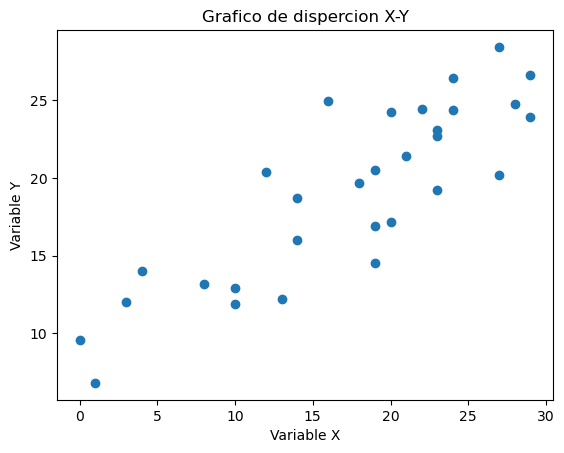

In [15]:
plt.scatter(datos['X'],datos['Y'])
plt.title('Grafico de dispercion X-Y')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.show()

De acuerdo con la grafica hay una relacion lineal entre X y Y, es plausible estimar un modelo lineal de MCO

In [16]:
## Estimar el modelo
## 1. Definir el modelo OlS es MCO en python
reg = smf.ols(formula = 'Y~X',data = datos)
## 2. Estimar el modelo
results = reg.fit()
## 3. Pedir que nos muestre el modelo 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     76.40
Date:                Wed, 23 Aug 2023   Prob (F-statistic):           1.72e-09
Time:                        15:40:26   Log-Likelihood:                -74.480
No. Observations:                  30   AIC:                             153.0
Df Residuals:                      28   BIC:                             155.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.9619      1.276      7.022      0.0

## P>|t| para la tabla de arriba 
para B0(Intercept) la hipotesis es H0: B0=0 

                           H1: B1=!0
                                   
 para B1(X)         la hipotesis es H0: B0=0
 
                     H1: B1=!0
                                   
 Pvalor = 0.000
 
 B0 = 8.96
 
 B1 = 0.58
 
    Intercepto: Pvalue<ALFA con un 95% de confianza Rechazamos H0; significa que el 
        intercepto es distinto de cero; estimamos un valor de 8.96
    
    B1:         Pvalor<ALFA con un 95% de confianza rechazamos H0; significa que 
        "X" afecta a "Y"
        en promedio, cuando "X" incrementa en una unidad "Y" incrementa 0.58
        
  El primer conjunto con el que se sacan los valores del modelo de B0 Y B1 se llama Concunto de Entrenamiento (Train SET), para obtener los betas
  
  Y el conjunto de datos con el que se trabaja los valores del modelo se llama Conjunto Evoluacion (Test SET) y esto para ver si los valores del modelo son buenos o no.
    

## VALIDACION CRUZADA

In [18]:
## Definir conjunto de entrenamiento (TRAIN SET)
train_set = datos.iloc[:20]
## DEfinir conjunto de Evaluacion (TEST SET)
test_set = datos.iloc[20:]

In [20]:
## la regresion se estima con el conjunto de entrenamiento 
reg1 = smf.ols(formula = 'Y~X', data = train_set)
results1 = reg1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     28.80
Date:                Wed, 23 Aug 2023   Prob (F-statistic):           4.23e-05
Time:                        16:10:50   Log-Likelihood:                -51.332
No. Observations:                  20   AIC:                             106.7
Df Residuals:                      18   BIC:                             108.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2336      2.008      4.598      0.0

In [21]:
## Vamos a pronosticar los valores del conjunto de evaluacion
test_set['Y_hat'] = results1.predict(test_set)

C:\Users\DELL\AppData\Local\Temp\ipykernel_4720\938619889.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set['Y_hat'] = results1.predict(test_set)


In [22]:
test_set

,X,Y,Y_hat
20,0,9.544102,9.233587
21,20,24.230330,20.117395
22,24,26.417826,22.294157
23,23,23.066723,21.749966
24,8,13.145005,13.587110
25,24,24.385156,22.294157
26,10,12.934102,14.675491
27,4,14.002469,11.410349
28,29,26.599047,25.015109
29,10,11.910387,14.675491


In [25]:
## MAD desviacion Absoluta Media 
## utlizar el MAD para ver que tan bien pronostica el modelo el conjunto de evaluacion
MAD = (test_set['Y']-test_set['Y_hat']).abs().mean()


In [26]:
MAD

2.107953156470989